In [97]:

import numpy as np
import matplotlib.pyplot as plt
from Kea.utils import plotting
plotting.modify_rc()

from sympy import *

x = symbols('x', positive=True, real=True)
k = symbols('k', positive=True, real=True)
s = symbols('\sigma_{b}', positive=True, real=True)
D = symbols('D', postive=True, integer=True)
#D = 3

PSF = exp(-x**2 / (2*s**2))/(2*pi*s**2)**(D/2)
E_PSF = exp(-k**2 * s**2 / 2)

display(PSF)
display(E_PSF)

ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*x) / (k*x / S(2))**(D/S(2) - S(1))
display(ftD)

# test = integrate(PSF*ftD, (x, 0, oo))
# display(test.simplify().subs({D: S(1)}).simplify())
# display(test.simplify().subs({D: S(2)}).simplify())


exp(-x**2/(2*\sigma_{b}**2))/(2*pi*\sigma_{b}**2)**(D/2)

exp(-\sigma_{b}**2*k**2/2)

(k*x/2)**(1 - D/2)*besselj(D/2 - 1, k*x)*gamma(D/2)

In [98]:

SF_PSF = integrate((1 - ftD) * E_PSF, (k, 0, oo))
display(SF_PSF.simplify().expand(func=True))
display(SF_PSF.subs({D: S(1)}).simplify())
display(SF_PSF.subs({D: S(2)}).simplify())
display(SF_PSF.subs({D: S(3)}).simplify())


-sqrt(2)*sqrt(pi)*hyper((1/2,), (D/2,), -x**2/(2*\sigma_{b}**2))/(2*\sigma_{b}) + sqrt(2)*sqrt(pi)/(2*\sigma_{b})

sqrt(2)*sqrt(pi)*(1 - exp(-x**2/(2*\sigma_{b}**2)))/(2*\sigma_{b})

sqrt(2)*sqrt(pi)*(1 - exp(-x**2/(4*\sigma_{b}**2))*besseli(0, x**2/(4*\sigma_{b}**2)))/(2*\sigma_{b})

-pi*erf(sqrt(2)*x/(2*\sigma_{b}))/(2*x) + sqrt(2)*sqrt(pi)/(2*\sigma_{b})

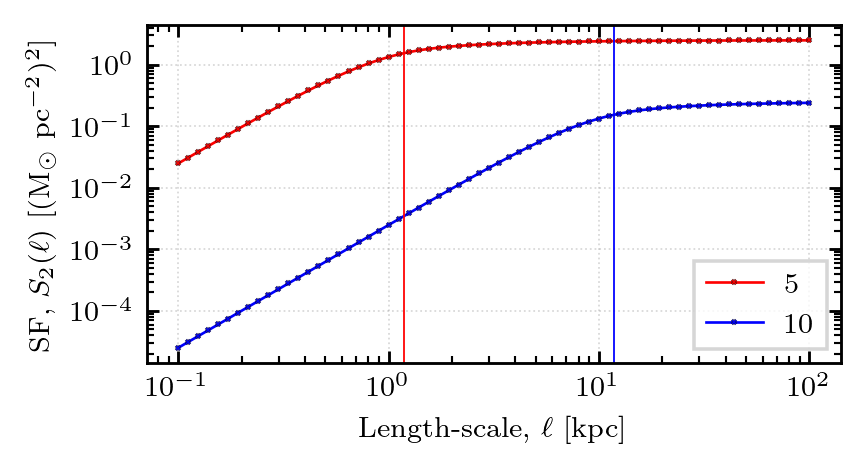

In [99]:

_l = np.exp(np.linspace(np.log(0.1), np.log(1e2), 64))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

sf1 = np.zeros_like(_l)
sf2 = np.zeros_like(_l)

sig1, sig2 = 0.5, 5

for i, __l in enumerate(_l):
    sf1[i] = float(SF_PSF.subs({x: __l, s: sig1, D: S(2)}).evalf())
    sf2[i] = float(SF_PSF.subs({x: __l, s: sig2, D: S(2)}).evalf())

ax.plot(_l, sf1, linestyle='-', color='red', linewidth=0.75, label='5', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
ax.plot(_l, sf2, linestyle='-', color='blue', linewidth=0.75, label='10', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_xlabel(r'Length-scale, $\ell$ [kpc]')
ax.set_ylabel(r'SF, $S_2(\ell)$ [(M$_\odot$ pc$^{-2}$)$^2$]')
ax.legend(fancybox=False)

to_FWHM = np.sqrt(8.*np.log(2.))

ax.axvline(sig1*to_FWHM, color='red', linestyle='-', linewidth=0.5)
ax.axvline(sig2*to_FWHM, color='blue', linestyle='-', linewidth=0.5)


In [100]:

alpha = diff(log(SF_PSF), x) * x
display(alpha.simplify().subs({D: S(1)}).simplify())

lim = limit(alpha.simplify().subs({D: S(1)}).simplify(), x, 0)
display(lim)


x**2/(\sigma_{b}**2*(exp(x**2/(2*\sigma_{b}**2)) - 1))

2

In [101]:

B, b = symbols('B, b', real=True)
eq_E_PSF = (B/b) * (S(1)/S(2) * x**2 * diff(SF_PSF, x))
eq_E_PSF = eq_E_PSF.subs({x: b/k})
display(eq_E_PSF.simplify())
display(eq_E_PSF.subs({D: S(1)}).simplify())
display(eq_E_PSF.subs({D: S(2)}).simplify())
display(eq_E_PSF.subs({D: S(3)}).simplify())


sqrt(2)*sqrt(pi)*B*b**2*hyper((3/2,), (D/2 + 1,), -b**2/(2*\sigma_{b}**2*k**2))/(4*D*\sigma_{b}**3*k**3)

sqrt(2)*sqrt(pi)*B*b**2*exp(-b**2/(2*\sigma_{b}**2*k**2))/(4*\sigma_{b}**3*k**3)

sqrt(2)*sqrt(pi)*B*b**2*(besseli(0, b**2/(4*\sigma_{b}**2*k**2)) - besseli(1, b**2/(4*\sigma_{b}**2*k**2)))*exp(-b**2/(4*\sigma_{b}**2*k**2))/(8*\sigma_{b}**3*k**3)

pi*B*erf(sqrt(2)*b/(2*\sigma_{b}*k))/(4*b) - sqrt(2)*sqrt(pi)*B*exp(-b**2/(2*\sigma_{b}**2*k**2))/(4*\sigma_{b}*k)

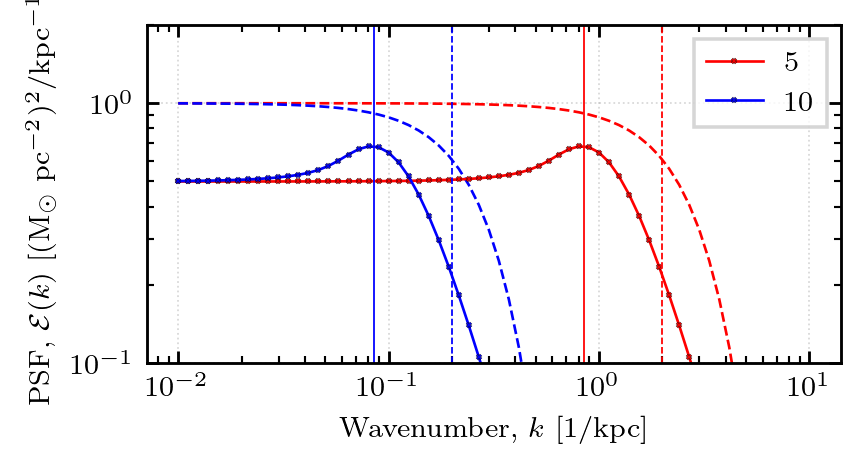

In [102]:

_k = np.exp(np.linspace(np.log(1e-2), np.log(1e1), 64))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

e0_1 = np.zeros_like(_k)
e0_2 = np.zeros_like(_k)
e1 = np.zeros_like(_k)
e2 = np.zeros_like(_k)

sig1, sig2 = 0.5, 5

for i, __k in enumerate(_k):
    e0_1[i] = float(E_PSF.subs({k: __k, s: sig1, D: S(2)}))
    e0_2[i] = float(E_PSF.subs({k: __k, s: sig2, D: S(2)}))

    e1[i] = float(eq_E_PSF.subs({k: __k, s: sig1, D: S(2), B: S(1), b: S(1)}).evalf())
    e2[i] = float(eq_E_PSF.subs({k: __k, s: sig2, D: S(2), B: S(1), b: S(1)}).evalf())

ax.plot(_k, e0_1, linestyle='--', color='red', linewidth=0.75)
ax.plot(_k, e0_2, linestyle='--', color='blue', linewidth=0.75)

ax.plot(_k, e1, linestyle='-', color='red', linewidth=0.75, label='5', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
ax.plot(_k, e2, linestyle='-', color='blue', linewidth=0.75, label='10', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')
ax.set_ylabel(r'PSF, $\mathcal{E}(k)$ [(M$_\odot$ pc$^{-2}$)$^2$/kpc$^{-1}$]')
ax.legend(fancybox=False)

ax.set_ylim((1e-1, 2e0))

to_FWHM = np.sqrt(8.*np.log(2.))

ax.axvline(1./(sig1*to_FWHM), color='red', linestyle='-', linewidth=0.5)
ax.axvline(1./(sig2*to_FWHM), color='blue', linestyle='-', linewidth=0.5)

ax.axvline(1./sig1, color='red', linestyle='--', linewidth=0.5)
ax.axvline(1./sig2, color='blue', linestyle='--', linewidth=0.5)


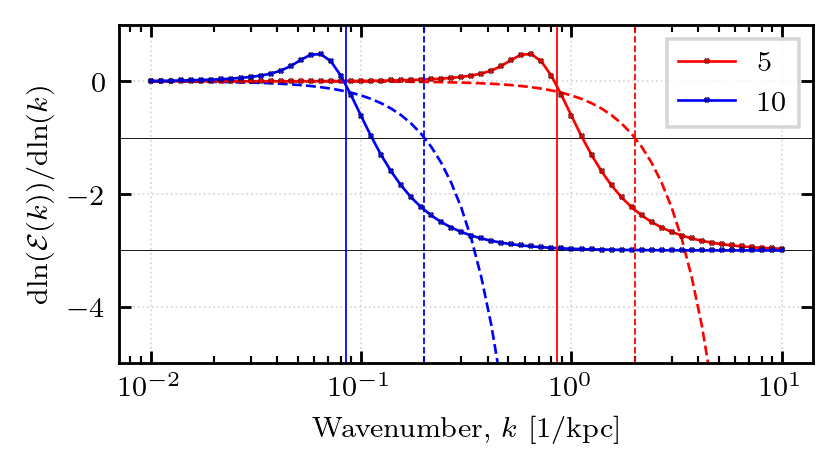

In [105]:

d_E_PSF = diff(log(E_PSF), k) * k
d_eq_E_PSF = diff(log(eq_E_PSF), k) * k

_k = np.exp(np.linspace(np.log(1e-2), np.log(1e1), 64))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

e0_1 = np.zeros_like(_k)
e0_2 = np.zeros_like(_k)
e1 = np.zeros_like(_k)
e2 = np.zeros_like(_k)

sig1, sig2 = 0.5, 5

for i, __k in enumerate(_k):
    e0_1[i] = float(d_E_PSF.subs({k: __k, s: sig1, D: S(2)}))
    e0_2[i] = float(d_E_PSF.subs({k: __k, s: sig2, D: S(2)}))

    e1[i] = float(d_eq_E_PSF.subs({k: __k, s: sig1, D: S(2), B: S(1), b: S(1)}).evalf())
    e2[i] = float(d_eq_E_PSF.subs({k: __k, s: sig2, D: S(2), B: S(1), b: S(1)}).evalf())

ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(_k, e0_1, linestyle='--', color='red', linewidth=0.75)
ax.plot(_k, e0_2, linestyle='--', color='blue', linewidth=0.75)

ax.plot(_k, e1, linestyle='-', color='red', linewidth=0.75, label='5', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
ax.plot(_k, e2, linestyle='-', color='blue', linewidth=0.75, label='10', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
#ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')
ax.set_ylabel(r'd$\ln({\mathcal{E}}(k))/$d$\ln(k)$')
ax.legend(fancybox=False)

ax.set_ylim((-5, 1))

to_FWHM = np.sqrt(8.*np.log(2.))

ax.axvline(1./(sig1*to_FWHM), color='red', linestyle='-', linewidth=0.5)
ax.axvline(1./(sig2*to_FWHM), color='blue', linestyle='-', linewidth=0.5)

ax.axvline(1./sig1, color='red', linestyle='--', linewidth=0.5)
ax.axvline(1./sig2, color='blue', linestyle='--', linewidth=0.5)
